In [1]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel('/content/Book1.xlsx')

print("Original DataFrame head:")
display(df.head())

Original DataFrame head:


,id,product,category,sub_category,brand,sale_price,market_price,type,rating
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4


In [2]:
# Remove rows with any null values
df_cleaned = df.dropna()

print("DataFrame head after removing null rows:")
display(df_cleaned.head())

DataFrame head after removing null rows:


,id,product,category,sub_category,brand,sale_price,market_price,type,rating
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4


In [3]:
print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

Original DataFrame shape: (27555, 9)
Cleaned DataFrame shape: (18928, 9)


### Step 1: Define Features (X) and Target (y)

We'll aim to predict `sale_price`. The `id` and `product` columns are not directly useful as numerical features, so we'll drop them for now. Other columns like `market_price`, `rating`, and categorical features (`category`, `sub_category`, `brand`, `type`) will be used as features.

In [4]:
# Define target variable
y = df_cleaned['sale_price']

# Define features (excluding 'id', 'product', and 'sale_price')
X = df_cleaned.drop(columns=['id', 'product', 'sale_price'])

display(X.head())

,category,sub_category,brand,market_price,type,rating
0,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,Hair Oil & Serum,4.1
1,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,Water & Fridge Bottles,2.3
2,Cleaning & Household,Pooja Needs,Trm,250.0,Lamp & Lamp Oil,3.4
3,Cleaning & Household,Bins & Bathroom Ware,Nakoda,176.0,"Laundry, Storage Baskets",3.7
4,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,Bathing Bars & Soaps,4.4


### Step 2: Preprocessing Categorical Features

Many machine learning models require numerical input. We'll use one-hot encoding for the categorical features (`category`, `sub_category`, `brand`, `type`). We'll use `ColumnTransformer` to apply this transformation only to the categorical columns.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = ['category', 'sub_category', 'brand', 'type']
numerical_features = ['market_price', 'rating']

# Convert categorical features to string type using .apply(str) for robustness
for col in categorical_features:
    X[col] = X[col].apply(str)

print("Verifying types of categorical features after conversion:")
for col in categorical_features:
    print(f"  Column '{col}': {X[col].apply(type).unique()}")

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply preprocessing to the features
X_processed = preprocessor.fit_transform(X)

print(f"Shape of processed features: {X_processed.shape}")

Verifying types of categorical features after conversion:
  Column 'category': [<class 'str'>]
  Column 'sub_category': [<class 'str'>]
  Column 'brand': [<class 'str'>]
  Column 'type': [<class 'str'>]
Shape of processed features: (18928, 2384)


### Step 3: Build a Predictive Model and Perform K-Fold Cross-Validation

We'll use a `RandomForestRegressor` as our predictive model. K-fold cross-validation will help us evaluate the model's performance on different subsets of the data, providing a more robust estimate of its generalization ability.

We will use `KFold` from `sklearn.model_selection` to split the data and train the model multiple times.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Initialize the model
model = RandomForestRegressor(random_state=42)

# Set up K-Fold cross-validation
n_splits = 5 # You can change the number of folds
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_scores = []
r2_scores = []

print(f"Performing {n_splits}-fold cross-validation...")

# Check if X_processed is a sparse matrix and convert to dense if necessary
if hasattr(X_processed, 'toarray'):
    X_processed_dense = X_processed.toarray()
else:
    X_processed_dense = X_processed

for fold, (train_index, test_index) in enumerate(kf.split(X_processed_dense)):
    X_train, X_test = X_processed_dense[train_index], X_processed_dense[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"Fold {fold+1}: MAE = {mae:.2f}, R2 = {r2:.2f}")

print("\n--- Cross-Validation Results ---")
print(f"Average MAE: {np.mean(mae_scores):.2f} (+/- {np.std(mae_scores):.2f})")
print(f"Average R2: {np.mean(r2_scores):.2f} (+/- {np.std(r2_scores):.2f})")

Performing 5-fold cross-validation...
Fold 1: MAE = 28.13, R2 = 0.93
Fold 2: MAE = 28.87, R2 = 0.95
Fold 3: MAE = 26.13, R2 = 0.94
Fold 4: MAE = 30.11, R2 = 0.92
Fold 5: MAE = 27.99, R2 = 0.93

--- Cross-Validation Results ---
Average MAE: 28.25 (+/- 1.30)
Average R2: 0.93 (+/- 0.01)


/tmp/ipykernel_2199/3108366242.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fold', y='MAE', data=cv_results, palette='viridis')
/tmp/ipykernel_2199/3108366242.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fold', y='R2', data=cv_results, palette='magma')


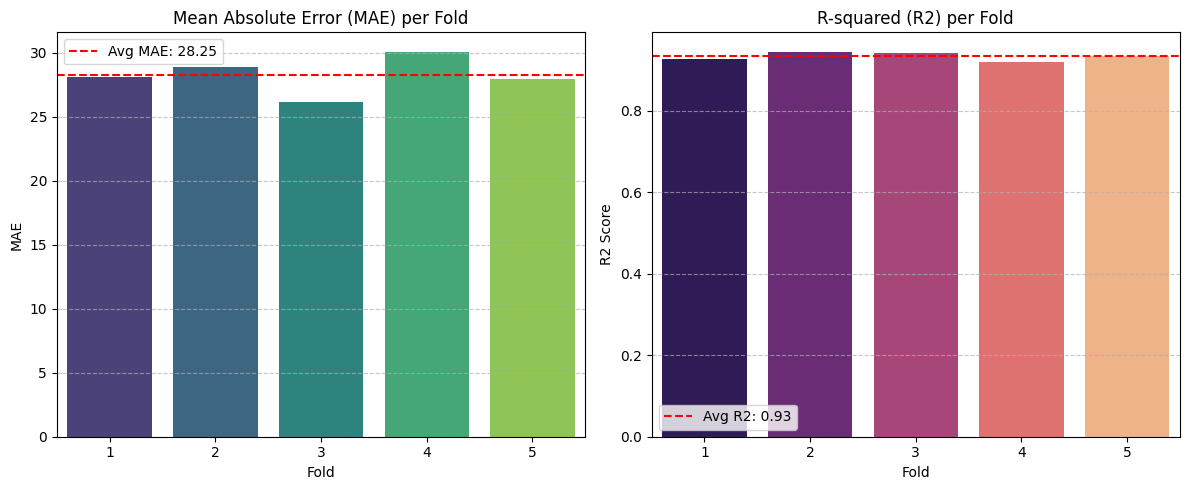

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting
cv_results = pd.DataFrame({
    'Fold': range(1, n_splits + 1),
    'MAE': mae_scores,
    'R2': r2_scores
})

# Plotting MAE scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Fold', y='MAE', data=cv_results, palette='viridis')
plt.axhline(np.mean(mae_scores), color='red', linestyle='--', label=f'Avg MAE: {np.mean(mae_scores):.2f}')
plt.title('Mean Absolute Error (MAE) per Fold')
plt.xlabel('Fold')
plt.ylabel('MAE')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plotting R2 scores
plt.subplot(1, 2, 2)
sns.barplot(x='Fold', y='R2', data=cv_results, palette='magma')
plt.axhline(np.mean(r2_scores), color='red', linestyle='--', label=f'Avg R2: {np.mean(r2_scores):.2f}')
plt.title('R-squared (R2) per Fold')
plt.xlabel('Fold')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

# Let's check performance on the full dataset training vs validation
# Train a final model on a split to compare train vs test directly

X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(
    X_processed_dense, y, test_size=0.2, random_state=42
)

eval_model = RandomForestRegressor(random_state=42)
eval_model.fit(X_train_eval, y_train_eval)

# Predictions
train_preds = eval_model.predict(X_train_eval)
test_preds = eval_model.predict(X_test_eval)

print("--- Overfitting Check ---")
print(f"Training R2:   {r2_score(y_train_eval, train_preds):.2f}  |  Validation R2:   {r2_score(y_test_eval, test_preds):.2f}")
print(f"Training MAE:  {mean_absolute_error(y_train_eval, train_preds):.2f} |  Validation MAE:  {mean_absolute_error(y_test_eval, test_preds):.2f}")

--- Overfitting Check ---
Training R2:   0.99  |  Validation R2:   0.93
Training MAE:  10.67 |  Validation MAE:  28.00
